<a href="https://colab.research.google.com/github/rsyadipras/PCVK_Ganjil2026/blob/main/Week6_21.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Risky Adi Prasetya - 244107020153 - TI-3E - 21
# Week6 — Filter Spasial: LPF, HPF, Point/Line/Edge Detection

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im



---


# Konvolusi tanpa library
Fungsi konvolusi dibuat manual, tidak memakai cv2.filter2D atau fungsi konvolusi OpenCV lainnya.

Parameter: image, kernel, stride, padding.

In [21]:
def convolution2d(image, kernel, stride=1, padding=0):
    img = image.astype(np.float64)
    kh, kw = kernel.shape
    if padding > 0:
        img = np.pad(img, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)
    H, W = img.shape
    out_h = (H - kh) // stride + 1
    out_w = (W - kw) // stride + 1
    out = np.zeros((out_h, out_w), dtype=np.float64)
    for y in range(out_h):
        for x in range(out_w):
            y0, x0 = y * stride, x * stride
            region = img[y0:y0 + kh, x0:x0 + kw]
            out[y, x] = np.sum(region * kernel)   # perkalian elemen + jumlahkan
    return np.clip(out, 0, 255).astype(np.uint8)

### Load citra dan ubah ke grayscale

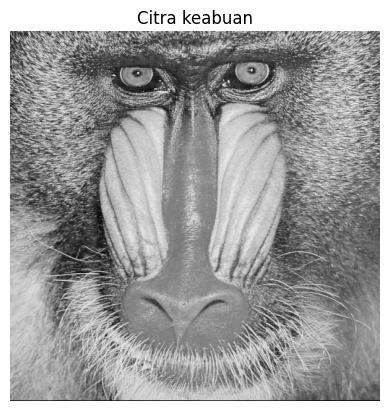

Ukuran citra: (512, 512)


In [22]:
img = cv.imread('/content/drive/MyDrive/PCVK2026/Images/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

plt.imshow(img_gray, cmap='gray')
plt.title('Citra keabuan')
plt.axis('off')
plt.show()

print('Ukuran citra:', img_gray.shape)

In [23]:
kernel_sharpen = np.array([[ 0, -1,  0],
                            [-1,  5, -1],
                            [ 0, -1,  0]], dtype=np.float64)

kernel_emboss  = np.array([[-2, -1,  0],
                            [-1,  1,  1],
                            [ 0,  1,  2]], dtype=np.float64)

kernel_left_sobel = np.array([[ 1, 0, -1],
                               [ 2, 0, -2],
                               [ 1, 0, -1]], dtype=np.float64)

# kernel Laplacian 3x3 (kernel canny)
kernel_laplacian = np.array([[-1, -1, -1],
                              [-1,  8, -1],
                              [-1, -1, -1]], dtype=np.float64)

# Gaussian 21x21 dibangun dari cv.getGaussianKernel
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel_1d = cv.getGaussianKernel(kernel_size, sigma)
kernel_gaussian21 = gaussian_kernel_1d @ gaussian_kernel_1d.transpose()

array([[  0,   0,   0, ...,   0,   0,   0],
       [  0, 255,   0, ..., 255, 255,   0],
       [  0, 255, 179, ..., 249, 218,   0],
       ...,
       [  0, 255, 255, ..., 159, 183,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], dtype=uint8)
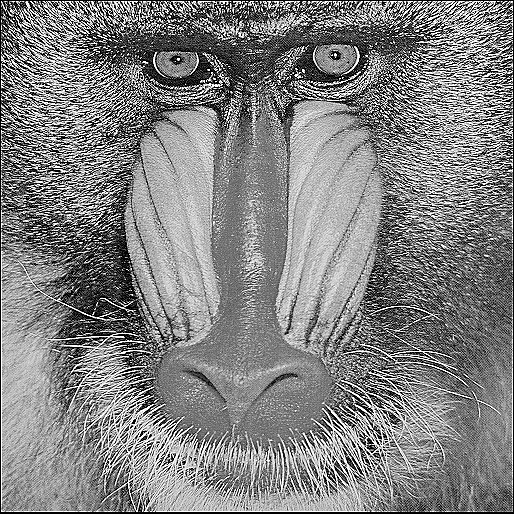

In [24]:
convolution2d(img_gray, kernel_sharpen, 1, 2)

### Penerapan Image Filter
Average filter, low pass filter, dan high pass filter, sharpen, emboss, Left Sobel Edge Detection, canny edge detection, 21x21 gaussian Blur

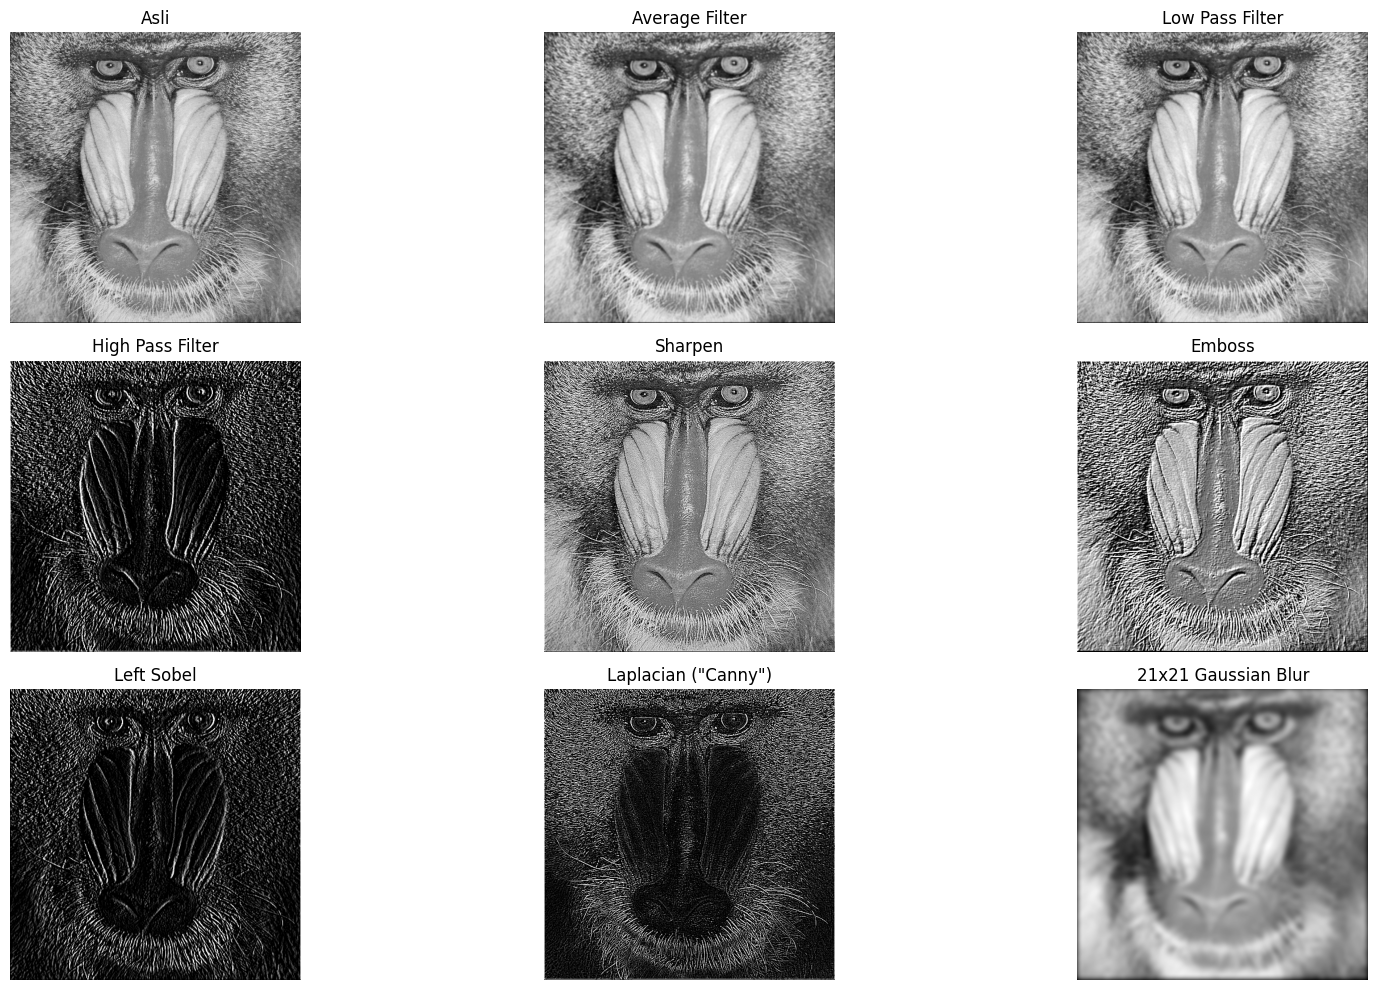

In [25]:
kernel_average = np.ones((3,3), dtype=np.float64) / 9
kernel_lpf     = np.array([[1,1,1],[1,4,1],[1,1,1]], dtype=np.float64) / 12
kernel_hpf     = np.array([[-1,0,1],[-1,0,3],[-3,0,1]], dtype=np.float64)

hasil_average  = convolution2d(img_gray, kernel_average,   stride=1, padding=1)
hasil_lpf      = convolution2d(img_gray, kernel_lpf,       stride=1, padding=1)
hasil_hpf      = convolution2d(img_gray, kernel_hpf,       stride=1, padding=1)
hasil_sharpen  = convolution2d(img_gray, kernel_sharpen,   stride=1, padding=1)
hasil_emboss   = convolution2d(img_gray, kernel_emboss,    stride=1, padding=1)
hasil_lsobel   = convolution2d(img_gray, kernel_left_sobel,stride=1, padding=1)
hasil_laplace  = convolution2d(img_gray, kernel_laplacian, stride=1, padding=1)
hasil_gauss21  = convolution2d(img_gray, kernel_gaussian21,stride=1, padding=10)

semua = [img_gray, hasil_average, hasil_lpf, hasil_hpf,
         hasil_sharpen, hasil_emboss, hasil_lsobel, hasil_laplace, hasil_gauss21]
judul = ['Asli', 'Average Filter', 'Low Pass Filter', 'High Pass Filter',
         'Sharpen', 'Emboss', 'Left Sobel', 'Laplacian ("Canny")', '21x21 Gaussian Blur']

plt.figure(figsize=(18, 10))
for i, (im_, t) in enumerate(zip(semua, judul), 1):
    plt.subplot(3, 3, i)
    plt.imshow(im_, cmap='gray')
    plt.title(t)
    plt.axis('off')
plt.tight_layout()
plt.show()